# Subscription Paywall A/B Test Analysis

This project evaluates whether presenting a **$4.99 weekly premium subscription as a 50% discount** increases conversion compared with the standard paywall.

## Test Groups

- **Group A - Control:** Standard $4.99 subscription offer
- **Group B - Variant:** The same $4.99 offer presented as a 50% discounted offer

## Objectives

- Validate the experiment dataset
- Calculate users, conversions, and conversion rates
- Measure absolute and relative lift
- Test statistical significance
- Estimate 95% confidence intervals
- Review performance over time
- Translate the findings into a business recommendation


## 1. Load and Validate the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import norm

df = pd.read_csv("../data/ab_test_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df.head()


                                user_id           timestamp test_group  conversion
0  7f6833e6-1141-4f20-b4b2-f1e31019b1fd 2023-07-04 04:40:56          a           0
1  e6a6e960-d3f3-4074-a516-ba1e609b211e 2023-07-06 00:26:45          b           0
2  4d3fbfa5-6847-410a-bac2-477f01d5f400 2023-07-10 20:24:34          b           0
3  361457d9-a044-48f7-981c-d67dc3861679 2023-07-20 07:04:50          b           0
4  285cd63d-7d03-427f-a062-1fa2dd2e77d6 2023-07-19 23:27:50          b           0

In [2]:
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicated user IDs:", df["user_id"].duplicated().sum())


Shape: (19998, 4)
Missing values: 0
Duplicated user IDs: 0


## 2. Experiment Summary

In [3]:
group_summary = df.groupby("test_group").agg(
    user_count=("user_id", "count"),
    conversion_count=("conversion", "sum"),
    conversion_rate=("conversion", "mean")
)

group_summary


            user_count  conversion_count  conversion_rate
test_group                                                
a                10013               611         0.061021
b                 9985               889         0.089034

In [4]:
test_start = df["timestamp"].min()
test_end = df["timestamp"].max()
test_duration = (test_end.date() - test_start.date()).days + 1

print("Test start:", test_start)
print("Test end:", test_end)
print("Test duration:", test_duration, "days")


Test start: 2023-07-03 01:42:34.034000
Test end: 2023-07-25 01:41:19.153000
Test duration: 23 days


## 3. Statistical Hypothesis Test

A **one-sided two-proportion z-test** is used because the predefined alternative hypothesis expects the variant to outperform the control.

- **H₀:** $p_B \leq p_A$
- **H₁:** $p_B > p_A$
- Significance level: $\alpha = 0.05$


In [5]:
conversion_a = group_summary.loc["a", "conversion_rate"]
conversion_b = group_summary.loc["b", "conversion_rate"]

x_a = group_summary.loc["a", "conversion_count"]
x_b = group_summary.loc["b", "conversion_count"]
n_a = group_summary.loc["a", "user_count"]
n_b = group_summary.loc["b", "user_count"]

pooled_rate = (x_a + x_b) / (n_a + n_b)
pooled_se = (pooled_rate * (1 - pooled_rate) * (1/n_a + 1/n_b)) ** 0.5
z_stat = (conversion_b - conversion_a) / pooled_se
p_value = norm.sf(z_stat)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4e}")
print("Decision: Reject H0" if p_value < 0.05 else "Decision: Fail to reject H0")


Z-statistic: 7.5197
P-value: 2.7456e-14
Decision: Reject H0


In [6]:
absolute_lift = conversion_b - conversion_a
relative_lift = absolute_lift / conversion_a

print(f"Control conversion rate: {conversion_a:.2%}")
print(f"Variant conversion rate: {conversion_b:.2%}")
print(f"Absolute lift: {absolute_lift * 100:.2f} percentage points")
print(f"Relative lift: {relative_lift:.2%}")


Control conversion rate: 6.10%
Variant conversion rate: 8.90%
Absolute lift: 2.80 percentage points
Relative lift: 45.91%


## 4. Confidence Intervals and Conversion Comparison

In [7]:
def normal_proportion_ci(successes, observations, alpha=0.05):
    rate = successes / observations
    z_critical = norm.ppf(1 - alpha / 2)
    se = (rate * (1 - rate) / observations) ** 0.5
    return rate - z_critical * se, rate + z_critical * se

ci_a = normal_proportion_ci(x_a, n_a)
ci_b = normal_proportion_ci(x_b, n_b)

print(f"Group A 95% CI: {ci_a[0]:.2%} - {ci_a[1]:.2%}")
print(f"Group B 95% CI: {ci_b[0]:.2%} - {ci_b[1]:.2%}")


Group A 95% CI: 5.63% - 6.57%
Group B 95% CI: 8.34% - 9.46%


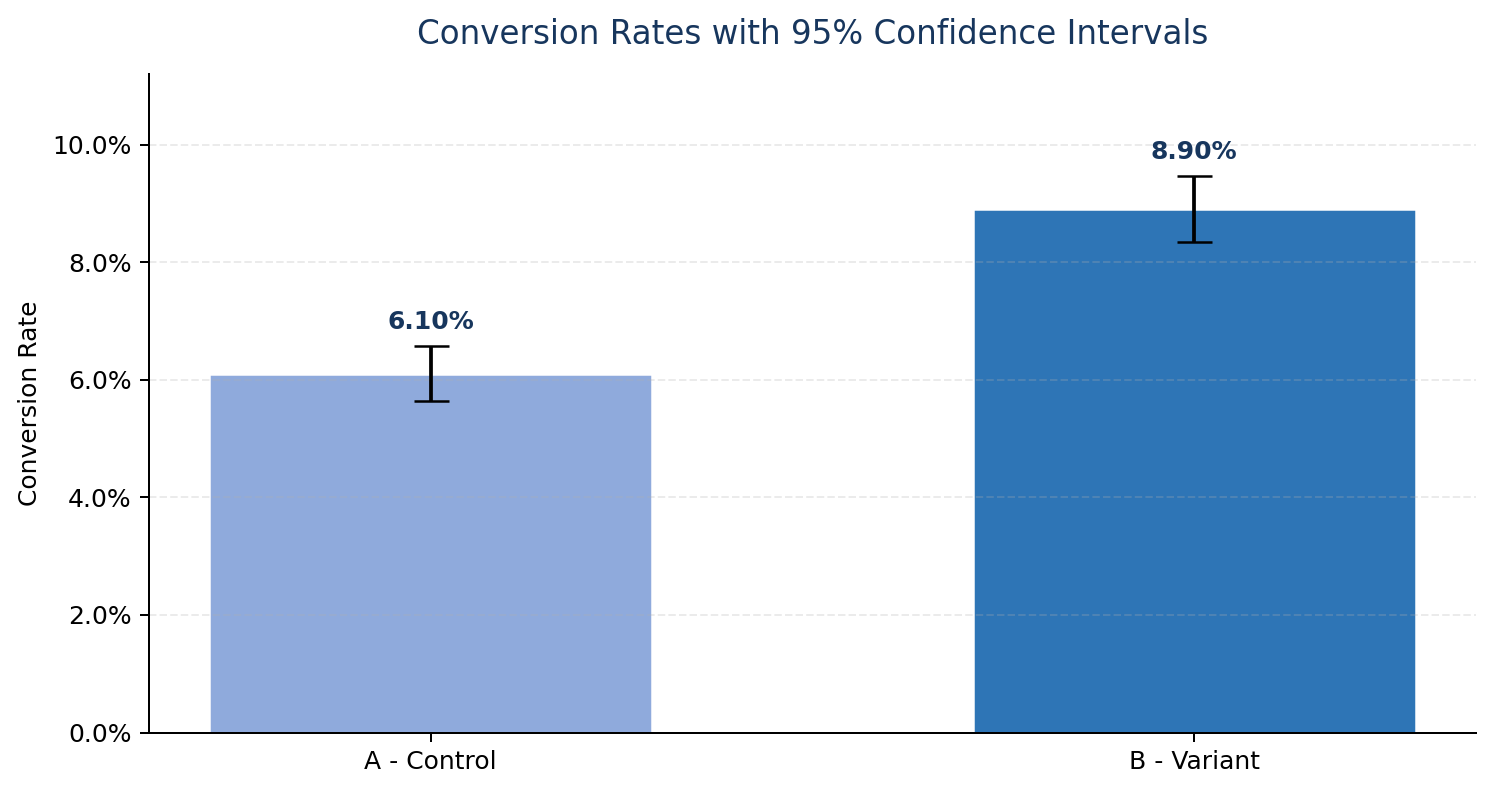

In [8]:
groups = ["A - Control", "B - Variant"]
rates = [conversion_a, conversion_b]
lower_errors = [conversion_a - ci_a[0], conversion_b - ci_b[0]]
upper_errors = [ci_a[1] - conversion_a, ci_b[1] - conversion_b]

fig, ax = plt.subplots(figsize=(8.4, 4.5))
bars = ax.bar(
    groups, rates, color=["#8FAADC", "#2E75B6"], width=0.58,
    yerr=[lower_errors, upper_errors], capsize=7
)

for bar, rate, ci_high in zip(bars, rates, [ci_a[1], ci_b[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, ci_high + 0.002,
            f"{rate:.2%}", ha="center", fontweight="bold")

ax.set_title("Conversion Rates with 95% Confidence Intervals")
ax.set_ylabel("Conversion Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 0.112)
ax.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


## 5. Conversion Performance Over Time

Only the **21 complete calendar days** from July 4 to July 24 are shown in the trend chart. Partial boundary days are excluded from this visualization to avoid misleading volatility. All users remain included in the primary hypothesis test.


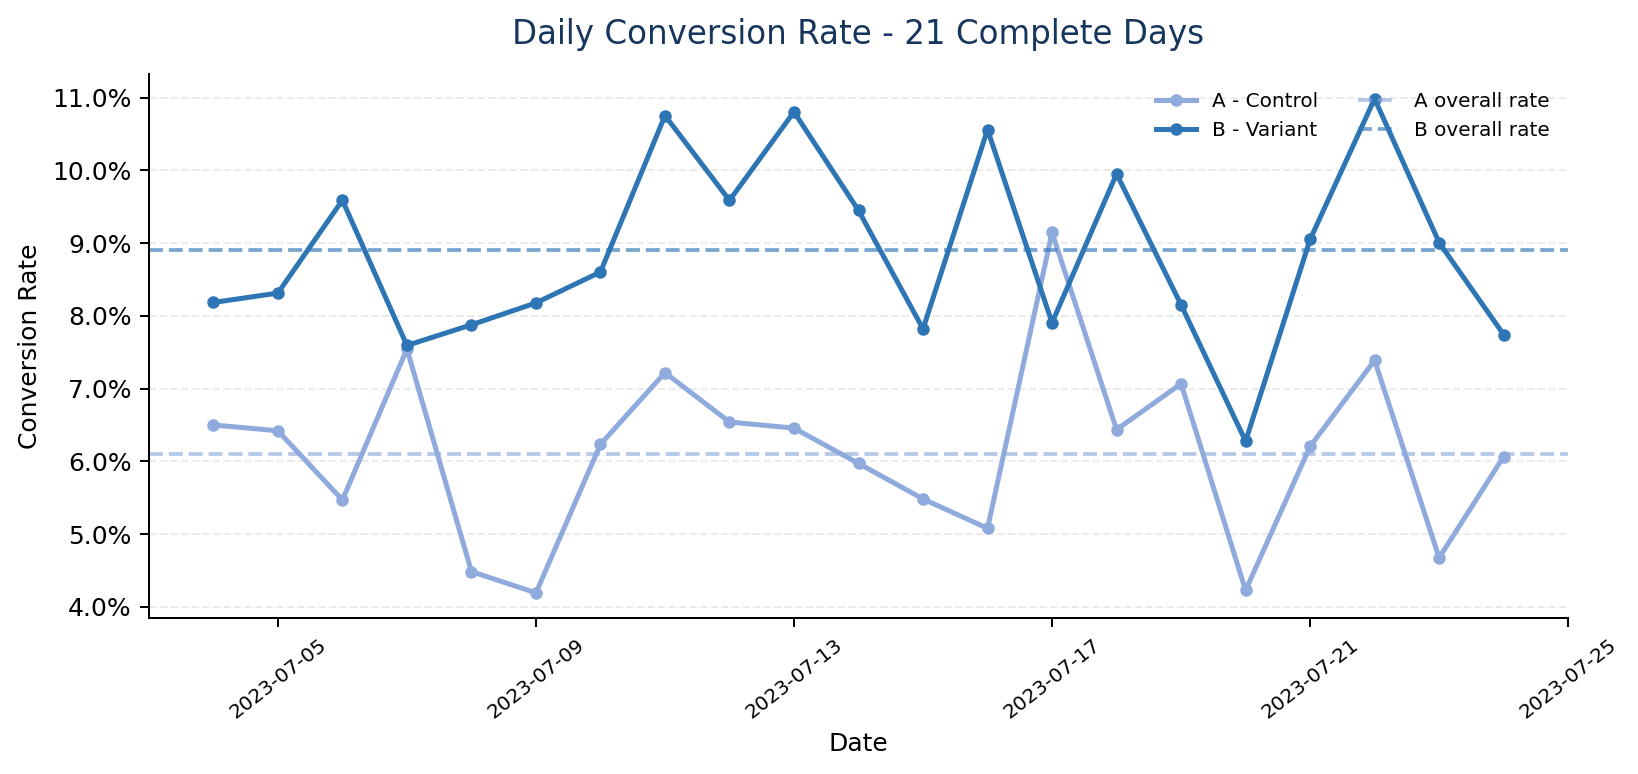

In [9]:
df["date"] = df["timestamp"].dt.date

daily_conversion = (
    df.groupby(["date", "test_group"])["conversion"]
      .mean()
      .unstack()
)

complete_days = daily_conversion[
    (daily_conversion.index > test_start.date()) &
    (daily_conversion.index < test_end.date())
]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(complete_days.index, complete_days["a"], marker="o", label="A - Control", color="#8FAADC")
ax.plot(complete_days.index, complete_days["b"], marker="o", label="B - Variant", color="#2E75B6")
ax.axhline(conversion_a, color="#8FAADC", linestyle="--", alpha=0.65, label="A overall rate")
ax.axhline(conversion_b, color="#2E75B6", linestyle="--", alpha=0.65, label="B overall rate")
ax.set_title("Daily Conversion Rate - 21 Complete Days")
ax.set_xlabel("Date")
ax.set_ylabel("Conversion Rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.tick_params(axis="x", rotation=40)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()


## 6. Conclusion and Business Recommendation

The variant increased conversion from **6.10% to 8.90%**, producing an absolute lift of **2.80 percentage points** and a relative lift of **45.91%**.

The one-sided two-proportion z-test returned **z = 7.52** and **p = 2.75e-14**, so the null hypothesis is rejected at the 5% significance level. The observed lift also exceeded the predefined +2 percentage-point minimum detectable effect.

**Recommendation:** Roll out the B variant gradually while monitoring conversion and adding guardrail metrics such as refunds/cancellations, revenue per paywall view, retention, and support complaints in a production environment.
